[실습문제] ======================================================
Wine 데이터셋을 이용한 PyTorch 다중 분류 모델 만들기
    Wine 데이터셋은 와인의 화학 성분을 이용하여 와인 종류를 분류하는 데이터입니다.

실습문제 1. Wine 데이터셋 불러오기
  sklearn.datasets의 load_wine()을 사용하여 데이터를 불러오시오.

실습문제 2. 데이터 기본 정보 확인하기
  Wine 데이터셋의 크기, 기초 통계량, 클래스별 개수를 확인하시오.

실습문제 3. 데이터 시각화하기
  와인 클래스별 데이터 개수를 그래프로 출력하시오.

실습문제 4. 입력 데이터와 정답 데이터 분리하기
  입력 데이터 X와 정답 데이터 y를 분리하시오.

실습문제 5. 학습용 / 테스트용 데이터 분리하기
  전체 데이터 중 80%는 학습용, 20%는 테스트용으로 분리하시오.

실습문제 6. 데이터 표준화하기
  StandardScaler를 사용하여 학습 데이터와 테스트 데이터를 표준화하시오.


임포트

In [2]:
# ============================================================
# 1. 기본 라이브러리 불러오기
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch 핵심 라이브러리
import torch

# 신경망 모델을 만들기 위한 모듈
import torch.nn as nn

# 최적화 알고리즘을 사용하기 위한 모듈
import torch.optim as optim

# PyTorch Dataset, DataLoader 사용
from torch.utils.data import TensorDataset, DataLoader

# Iris 데이터셋
# from sklearn.datasets import load_iris
from sklearn.datasets import load_wine

# 학습용 / 테스트용 데이터 분리
from sklearn.model_selection import train_test_split

# 데이터 표준화
from sklearn.preprocessing import StandardScaler

# 평가 지표
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# 2. 실행 장치 설정 - GPU 사용 가능 여부 확인
# ============================================================

# Colab에서 GPU를 켜면 cuda 사용 가능
# GPU가 없으면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)


사용 장치: cpu


실습문제 1. Wine 데이터셋 불러오기
  sklearn.datasets의 load_wine()을 사용하여 데이터를 불러오시오.

In [3]:
wine = load_wine()

# 입력 데이터
X = wine.data

# 정답 데이터
y = wine.target

feature_names = wine.feature_names
target_names = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["target_name"] = df["target"].apply(lambda x: target_names[x])

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


실습문제 2. 데이터 기본 정보 확인하기
  Wine 데이터셋의 크기, 기초 통계량, 클래스별 개수를 확인하시오.

In [9]:

print("데이터 크기:", df.shape)
print('---------------------------')

print("\n기초 통계량:")
print(df.describe())
print('---------------------------')

print("\n클레스별 개수:")
print(df["target_name"].value_counts())
print('---------------------------')


데이터 크기: (178, 15)
---------------------------

기초 통계량:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859   

실습문제 3. 데이터 시각화하기
  와인 클래스별 데이터 개수를 그래프로 출력하시오.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loca

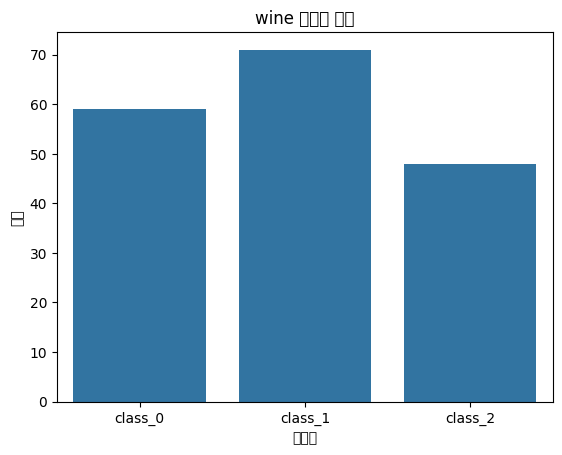

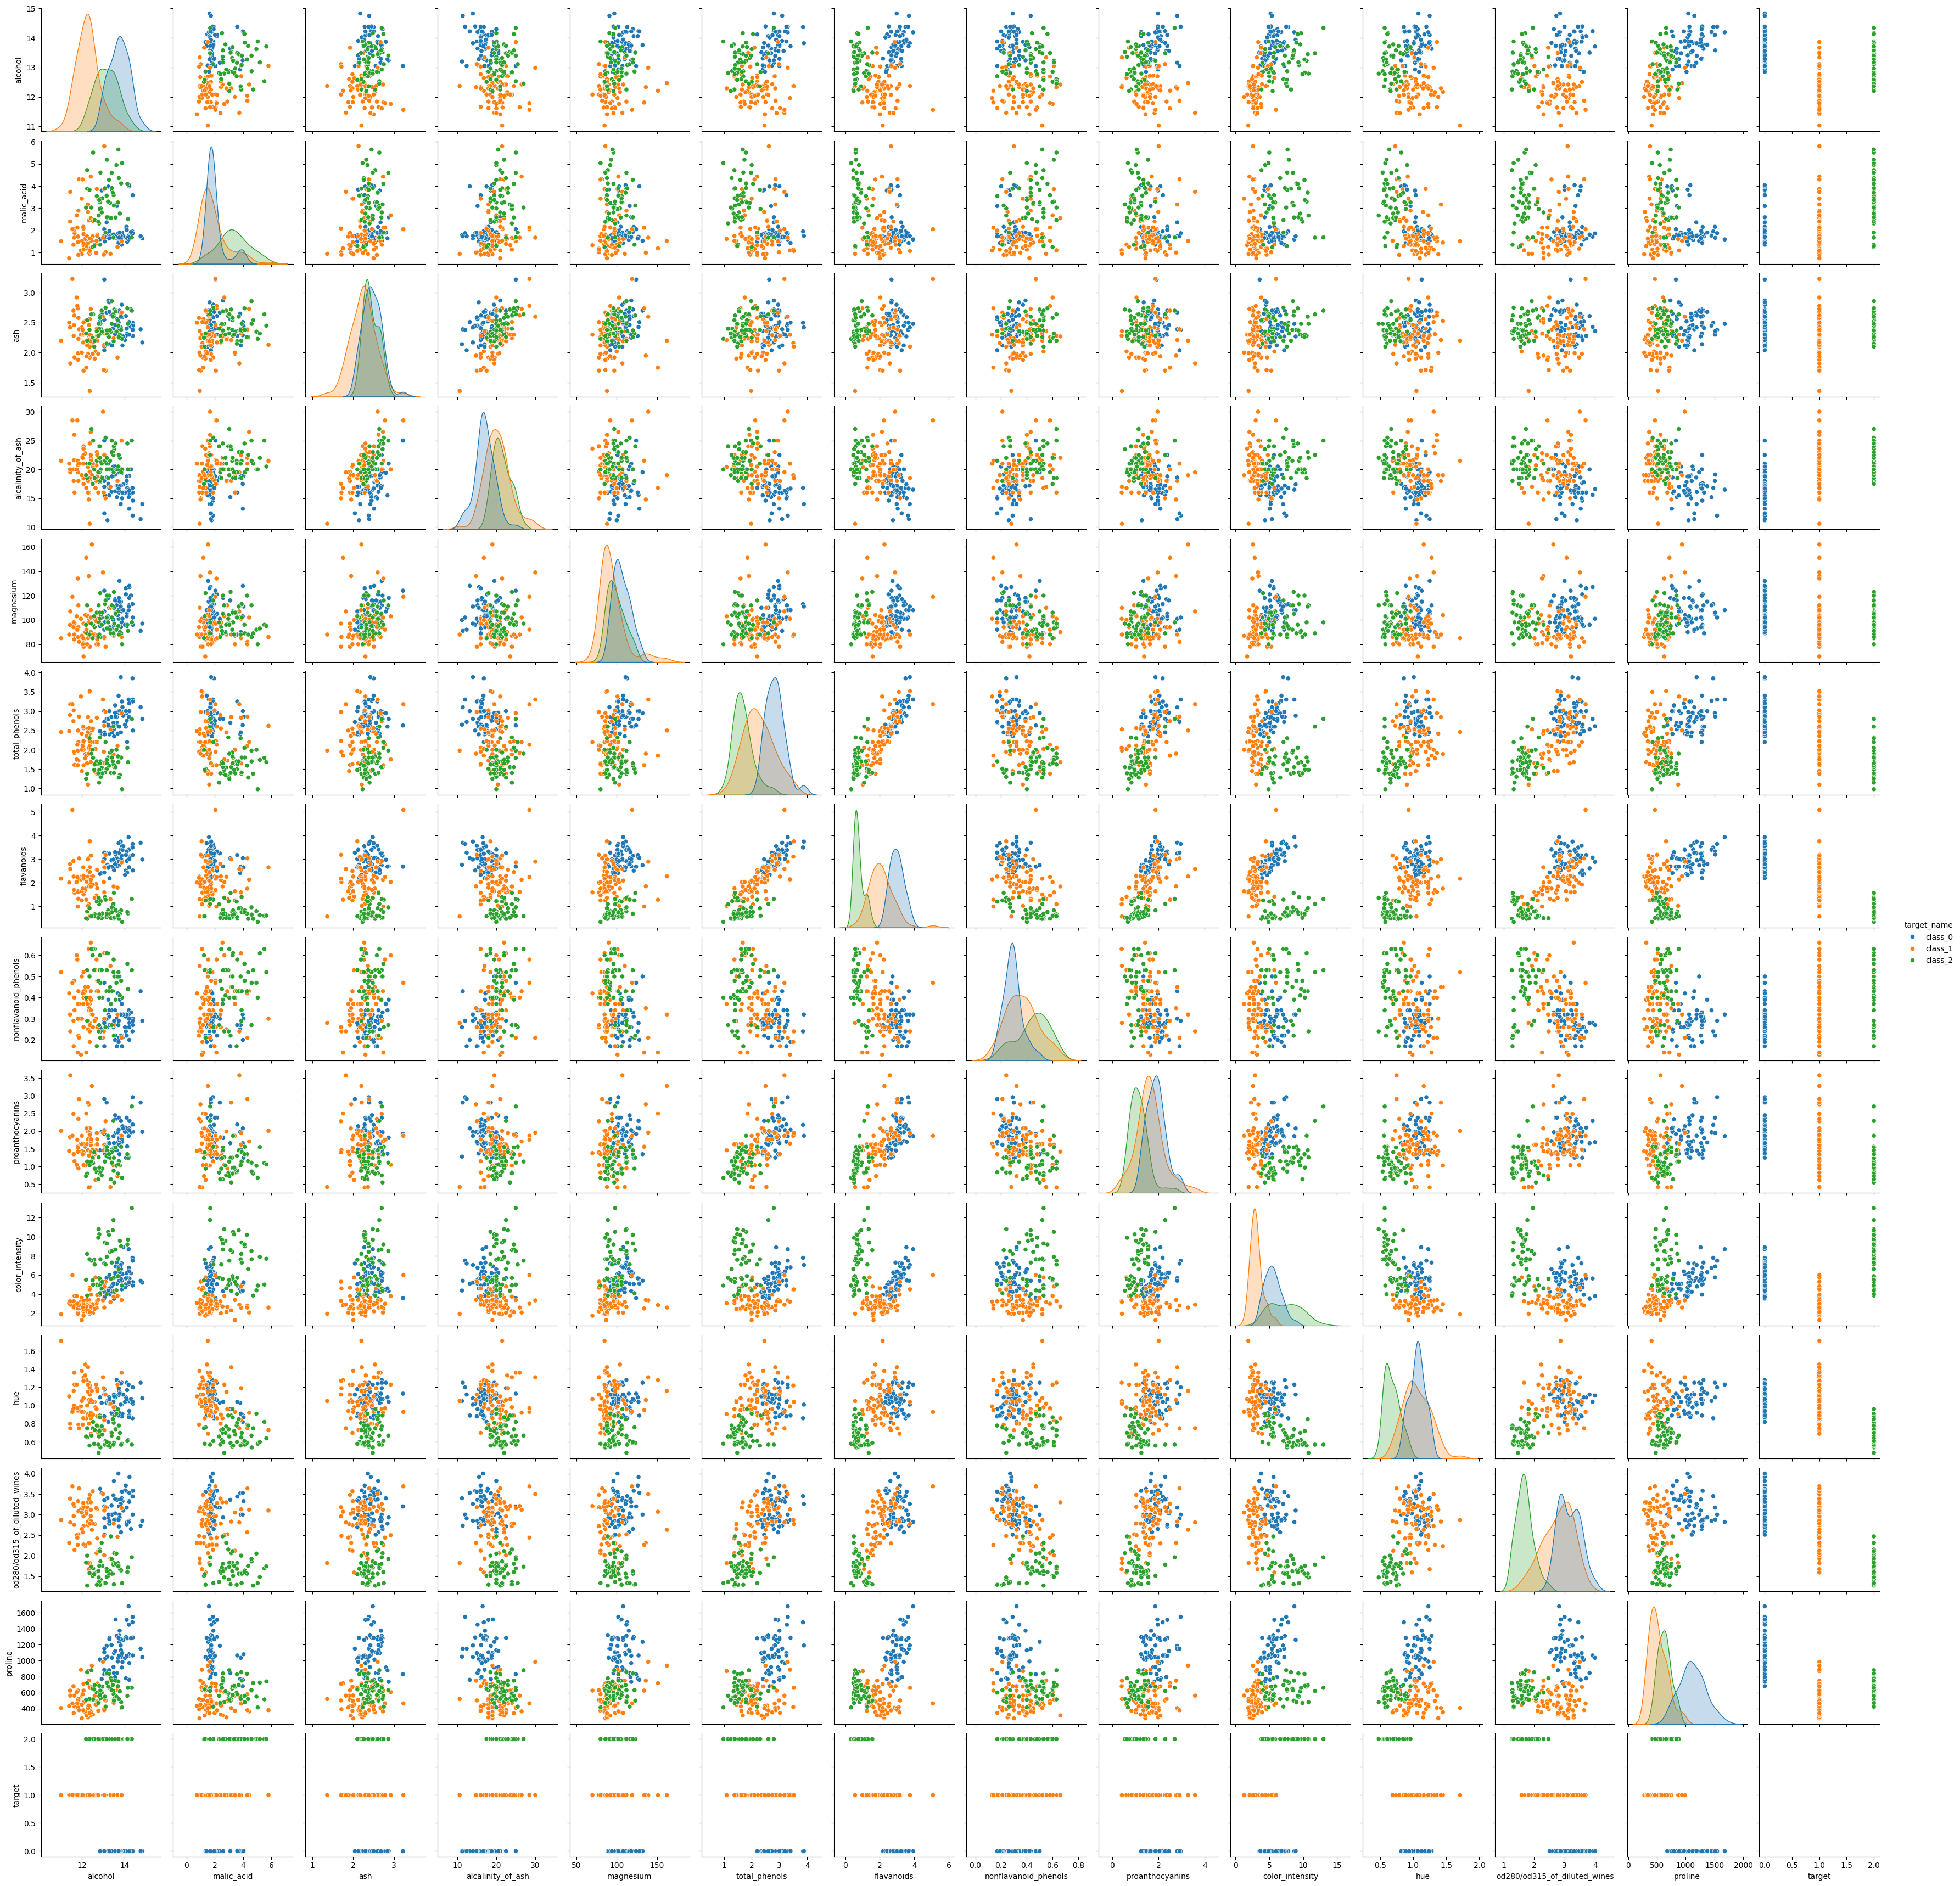

In [5]:

sns.countplot(data=df, x="target_name")
plt.title("wine 데이터 개수")
plt.xlabel("클래스")
plt.ylabel("개수")
plt.show()

sns.pairplot(df, hue="target_name")
plt.show()

실습문제 4. 입력 데이터와 정답 데이터 분리하기
  입력 데이터 X와 정답 데이터 y를 분리하시오.

In [6]:
X = df[feature_names].values
y = df["target"].values

print("입력 데이터 크기:", X.shape)
print("정답 데이터 크기:", y.shape)

입력 데이터 크기: (178, 13)
정답 데이터 크기: (178,)


실습문제 5. 학습용 / 테스트용 데이터 분리하기
  전체 데이터 중 80%는 학습용, 20%는 테스트용으로 분리하시오.\


In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("학습용 입력 데이터:", X_train.shape)
print("테스트용 입력 데이터:", X_test.shape)

학습용 입력 데이터: (142, 13)
테스트용 입력 데이터: (36, 13)


실습문제 6. 데이터 표준화하기
  StandardScaler를 사용하여 학습 데이터와 테스트 데이터를 표준화하시오.

In [8]:

scaler = StandardScaler()

# 학습 데이터 기준으로 평균과 표준편차 계산 후 변환
X_train_scaled = scaler.fit_transform(X_train)

# 테스트 데이터는 학습 데이터 기준으로만 변환
X_test_scaled = scaler.transform(X_test)